# PHQ-8 Depression Detection — 3-Block CNN (Regression)

**Architecture**: 3 convolutional blocks (Conv2D → BatchNorm → ReLU → MaxPool), adaptive average pooling, fully-connected layers with dropout, MSE regression head.

**Input**: log-mel spectrograms `(1, 128, 801)` saved as `.npy` files.

**Target**: PHQ-8 score (continuous, 0–24).

## 1. Imports & Configuration

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

# Paths
BASE_DIR = Path(".")
PROCESSED_DIR = BASE_DIR / "processed"
META_CSV = PROCESSED_DIR / "segment_metadata.csv"
SPEC_ROOT = PROCESSED_DIR / "spectrograms"
SAVE_DIR = BASE_DIR / "best_model" / "3_cnn_block"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Training hyper-parameters 
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
CHECKPOINT_FREQ = 10
EARLY_STOPPING_PATIENCE = 10   # stop if dev loss doesn't improve for this many epochs
NUM_WORKERS = 0

# Device 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("  WARNING: No GPU detected — training will be significantly slower.")
print(f"Checkpoints will be saved to: {SAVE_DIR.resolve()}")

Using device: cuda
Checkpoints will be saved to: C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\best_model\3_cnn_block


## 2. Dataset

In [ ]:
class SpectrogramDataset(Dataset):
    """
    Loads log-mel spectrograms from .npy files under
    processed/spectrograms/{train|dev|test}/.
    Paths are constructed directly from (split, participant_id, segment_idx)
    so no zip file is ever touched.
    """

    def __init__(self, meta_df: pd.DataFrame, spec_root: Path, split: str):
        self.meta = meta_df.reset_index(drop=True)
        self.split_dir = spec_root / split   # e.g. processed/spectrograms/train/

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        pid = int(row["participant_id"])
        seg = int(row["segment_idx"])
        # Always resolved from the split sub-folder — never touches a zip
        spec_path = self.split_dir / f"{pid}_seg{seg:04d}.npy"
        spec = np.load(spec_path).astype(np.float32)  # (128, n_frames)
        spec = torch.from_numpy(spec).unsqueeze(0)    # (1, 128, n_frames)
        label = torch.tensor(float(row["phq_score"]), dtype=torch.float32)
        return spec, label

def build_loaders(meta_csv: Path, spec_root: Path, batch_size: int, num_workers: int):
    meta = pd.read_csv(meta_csv)
    splits = {}
    for split in ("train", "dev", "test"):
        df = meta[meta["split"] == split].reset_index(drop=True)
        ds = SpectrogramDataset(df, spec_root, split)
        shuffle = (split == "train")
        splits[split] = DataLoader(
            ds, batch_size=batch_size, shuffle=shuffle,
            num_workers=num_workers, pin_memory=True
        )
        print(f"  {split:5s}: {len(df):6,} segments  →  {ds.split_dir}")
    return splits

print("Building data loaders…")
loaders = build_loaders(META_CSV, SPEC_ROOT, BATCH_SIZE, NUM_WORKERS)
train_loader = loaders["train"]
dev_loader   = loaders["dev"]
test_loader  = loaders["test"]

Building data loaders…
  train: 11,362 segments  →  processed\spectrograms\train
  dev  :  4,322 segments  →  processed\spectrograms\dev
  test :  5,904 segments  →  processed\spectrograms\test


In [11]:
# print number of control and depressed samples in each split
meta = pd.read_csv(META_CSV)
for split in ("train", "dev", "test"):
    df = meta[meta["split"] == split]
    num_control = (df["phq_score"] < 10).sum()
    num_depressed = (df["phq_score"] >= 10).sum()
    print(f"{split:5s}: {num_control:6,} control, {num_depressed:6,} depressed")

train:  8,009 control,  3,353 depressed
dev  :  2,590 control,  1,732 depressed
test :  4,281 control,  1,623 depressed


## 3. Model — 3-Block CNN Regression

In [ ]:
class ConvBlock(nn.Module):
    """Conv2D → BatchNorm → ReLU → MaxPool2d"""

    def __init__(self, in_ch: int, out_ch: int,
                 kernel: int = 3, pool: int = 2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel, padding=kernel // 2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=pool, stride=pool),
        )

    def forward(self, x):
        return self.block(x)

class CNN3BlockRegressor(nn.Module):
    """
    3-block CNN for PHQ-8 regression.

    Input  : (B, 1, 128, 801)  — log-mel spectrogram
    Output : (B,)              — predicted PHQ-8 score
    """
    def __init__(self, dropout: float = 0.5):
        super().__init__()

        # Convolutional backbone 
        self.conv_blocks = nn.Sequential(
            ConvBlock(in_ch=1,   out_ch=32,  kernel=3, pool=2),   # → (32,  64, 400)
            ConvBlock(in_ch=32,  out_ch=64,  kernel=3, pool=2),   # → (64,  32, 200)
            ConvBlock(in_ch=64,  out_ch=128, kernel=3, pool=2),   # → (128, 16, 100)
        )

        # Adaptive pooling → fixed-size feature vector 
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))          # → (128, 4, 4)

        # Regression head 
        self.head = nn.Sequential(
            nn.Flatten(),                                           # → 128*4*4 = 2048
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1),                                       # scalar output
        )

    def forward(self, x):
        x = self.conv_blocks(x)      # (B, 128, 16, ~100)
        x = self.adaptive_pool(x)    # (B, 128, 4, 4)
        x = self.head(x)             # (B, 1)
        return x.squeeze(1)          # (B,)

model = CNN3BlockRegressor(dropout=0.4).to(DEVICE)

# Quick shape sanity-check
with torch.no_grad():
    dummy = torch.zeros(2, 1, 128, 801, device=DEVICE)
    out = model(dummy)
    print(f"Output shape: {out.shape}  (expected: (2,))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Output shape: torch.Size([2])  (expected: (2,))
Trainable parameters: 633,953


## 4. Training Loop

In [ ]:
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {"train_loss": [], "dev_loss": [], "dev_rmse": []}
best_dev_loss   = float("inf")
epochs_no_improve = 0          # early-stopping counter

def run_epoch(loader, train: bool, desc: str):
    model.train(train)
    total_loss, total_samples = 0.0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        pbar = tqdm(loader, desc=desc, leave=False, unit="batch", dynamic_ncols=True)
        for specs, labels in pbar:
            specs  = specs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            preds  = model(specs)
            loss   = criterion(preds, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss    += loss.item() * len(labels)
            total_samples += len(labels)
            pbar.set_postfix({"loss": f"{total_loss / total_samples:.4f}"})
    mse  = total_loss / total_samples
    rmse = mse ** 0.5
    return mse, rmse

print(f"{'Epoch':>6}  {'Train MSE':>10}  {'Dev MSE':>10}  {'Dev RMSE':>10}")
print("-" * 44)

epoch_bar = tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs", unit="epoch")

for epoch in epoch_bar:

    train_mse, _ = run_epoch(train_loader, train=True,  desc=f"Ep {epoch:03d} train")
    dev_mse,   dev_rmse = run_epoch(dev_loader,   train=False, desc=f"Ep {epoch:03d} dev  ")

    history["train_loss"].append(train_mse)
    history["dev_loss"].append(dev_mse)
    history["dev_rmse"].append(dev_rmse)

    epoch_bar.set_postfix({
        "train_mse": f"{train_mse:.4f}",
        "dev_mse":   f"{dev_mse:.4f}",
        "dev_rmse":  f"{dev_rmse:.4f}",
    })
    print(f"{epoch:6d}  {train_mse:10.4f}  {dev_mse:10.4f}  {dev_rmse:10.4f}")

    # Checkpoint
    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_3cnn.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_mse":            train_mse,
            "dev_mse":              dev_mse,
        }, ckpt_path)
        print(f"  ↳ Checkpoint saved → {ckpt_path.name}")

    # Save best / early stopping
    if dev_mse < best_dev_loss:
        best_dev_loss = dev_mse
        epochs_no_improve = 0
        best_path = SAVE_DIR / "3_cnn_best.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "dev_mse":              dev_mse,
            "dev_rmse":             dev_rmse,
        }, best_path)
        print(f"  ↳ Best model saved  → {best_path.name}  (dev MSE {dev_mse:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\n  Early stopping triggered — no improvement for {EARLY_STOPPING_PATIENCE} epochs.")
            break

print("\nTraining complete.")
print(f"Best dev MSE : {best_dev_loss:.4f}  |  RMSE : {best_dev_loss**0.5:.4f}")

 Epoch   Train MSE     Dev MSE    Dev RMSE
--------------------------------------------


Epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]

Ep 001 train:   0%|          | 0/178 [00:00<?, ?batch/s]

Ep 001 dev  :   0%|          | 0/68 [00:00<?, ?batch/s]

     1     30.1819     52.7018      7.2596
  ↳ Best model saved  → 3_cnn_best.pth  (dev MSE 52.7018)


...

Ep 010 dev  :   0%|          | 0/68 [00:00<?, ?batch/s]

    10     15.4456     63.5693      7.9730
  ↳ Checkpoint saved → epoch10_3cnn.pth


Ep 011 train:   0%|          | 0/178 [00:00<?, ?batch/s]

Ep 011 dev  :   0%|          | 0/68 [00:00<?, ?batch/s]

    11     15.4342     64.6598      8.0411

  Early stopping triggered — no improvement for 10 epochs.

Training complete.
Best dev MSE : 52.7018  |  RMSE : 7.2596


## 5. Training Curves

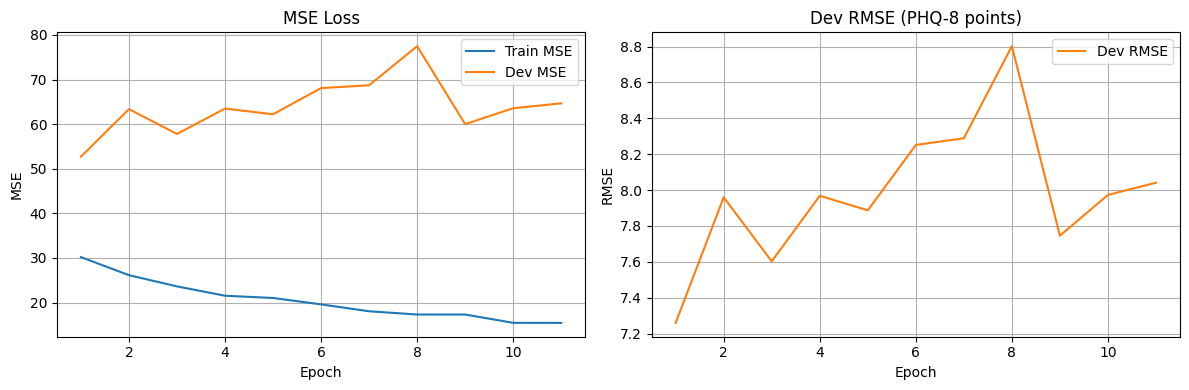

In [17]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Train MSE")
axes[0].plot(epochs, history["dev_loss"],   label="Dev MSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("MSE Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history["dev_rmse"], color="tab:orange", label="Dev RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Dev RMSE (PHQ-8 points)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Evaluation on Test Set

Load the best model and evaluate on the held-out test split. Metrics reported:
- **MSE** — mean squared error
- **RMSE** — root MSE (in PHQ-8 points)
- **MAE** — mean absolute error
- **Pearson r** — correlation between predicted and true scores

In [15]:
from scipy.stats import pearsonr

# Load best weights 
best_ckpt = torch.load(SAVE_DIR / "3_cnn_best.pth", map_location=DEVICE)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"Loaded best model from epoch {best_ckpt['epoch']}  "
      f"(dev MSE {best_ckpt['dev_mse']:.4f})")

# Collect predictions 
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for specs, labels in test_loader:
        specs = specs.to(DEVICE, non_blocking=True)
        preds = model(specs).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrics 
test_mse  = float(np.mean((all_preds - all_labels) ** 2))
test_rmse = test_mse ** 0.5
test_mae  = float(np.mean(np.abs(all_preds - all_labels)))
test_r, _ = pearsonr(all_preds, all_labels)

print("\n── Test-set results ───────────────────────────────")
print(f"  MSE       : {test_mse:.4f}")
print(f"  RMSE      : {test_rmse:.4f}  PHQ-8 points")
print(f"  MAE       : {test_mae:.4f}  PHQ-8 points")
print(f"  Pearson r : {test_r:.4f}")

C:\Users\edgar\AppData\Local\Temp\ipykernel_48320\4245379016.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_ckpt = torch.load(SAVE_DIR / "3_cnn_best.pth", map_loca

Loaded best model from epoch 1  (dev MSE 52.7018)

── Test-set results ───────────────────────────────
  MSE       : 34.7042
  RMSE      : 5.8910  PHQ-8 points
  MAE       : 4.9021  PHQ-8 points
  Pearson r : 0.0015


## 7. Prediction Distribution

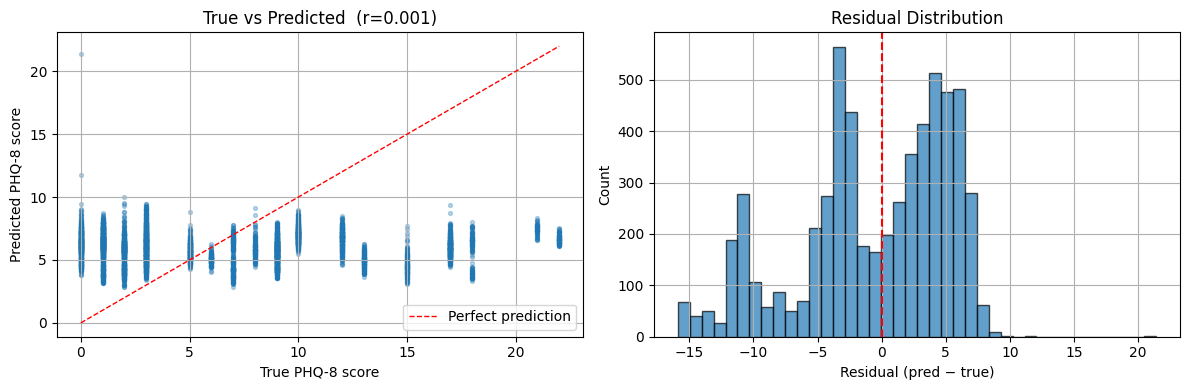

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter: true vs predicted
axes[0].scatter(all_labels, all_preds, alpha=0.3, s=8)
lo, hi = min(all_labels.min(), all_preds.min()), max(all_labels.max(), all_preds.max())
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("True PHQ-8 score")
axes[0].set_ylabel("Predicted PHQ-8 score")
axes[0].set_title(f"True vs Predicted  (r={test_r:.3f})")
axes[0].legend()
axes[0].grid(True)

# Residuals histogram
residuals = all_preds - all_labels
axes[1].hist(residuals, bins=40, edgecolor="k", alpha=0.7)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual (pred − true)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")
axes[1].grid(True)

plt.tight_layout()
plt.show()